In [11]:
from datetime import datetime
import socket
import platform

print("=" * 60)
print("NLP Assignment 1 - Execution Details")
print("=" * 60)
print("Execution Timestamp :", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("VM ID               :", socket.gethostname())
print("Platform            :", platform.platform())
print("=" * 60)

NLP Assignment 1 - Execution Details
Execution Timestamp : 2026-06-15 12:29:46
VM ID               : 2025ab05229
Platform            : Linux-5.14.0-503.31.1.el9_5.x86_64-x86_64-with-glibc2.34


In [12]:
GROUP_NUMBER = 128
TEAM_MEMBERS = [
    # (Name, BITS ID, Contribution %)
    ("NARESH", "2025aa05111@wilp.bits-pilani.ac.in", "100%"),
    ("SUHANI BHARGAVA", "2025aa05861@wilp.bits-pilani.ac.in", "100%"),
    ("SHANMUGAM MADHUMATHI", "2025aa05231@wilp.bits-pilani.ac.in", "100%"),
    ("RAJEEV MUDGAL", "2025aa05842@wilp.bits-pilani.ac.in", "100%"),
    ("KUTAREKAR NISHCHAL AJAY", "2025ab05229@wilp.bits-pilani.ac.in", "100%")
]

print(f"Group Number : {GROUP_NUMBER}")
print("Domain       : Domain 5 - Travel Blogs / Itineraries")
print("Team members :")
for name, bits_id, contrib in TEAM_MEMBERS:
    print(f"  {name:<25} {bits_id:<12} contribution: {contrib}")

Group Number : 128
Domain       : Domain 5 - Travel Blogs / Itineraries
Team members :
  NARESH                    2025aa05111@wilp.bits-pilani.ac.in contribution: 100%
  SUHANI BHARGAVA           2025aa05861@wilp.bits-pilani.ac.in contribution: 100%
  SHANMUGAM MADHUMATHI      2025aa05231@wilp.bits-pilani.ac.in contribution: 100%
  RAJEEV MUDGAL             2025aa05842@wilp.bits-pilani.ac.in contribution: 100%
  KUTAREKAR NISHCHAL AJAY   2025ab05229@wilp.bits-pilani.ac.in contribution: 100%


## Task 1 — Dataset Loading, Parsing, Tagging & Frequency Distribution

Download three Mark Twain travel narratives from Project Gutenberg, tokenise and sentence-split them with NLTK, and compute a word-frequency distribution over the first 10,000 sentences.

TASK 1 — Dataset loading, parsing, tagging, frequency distribution
Dataset source: Project Gutenberg public-domain travel narratives
  - innocents_abroad.txt: https://www.gutenberg.org/cache/epub/3176/pg3176.txt
  - tramp_abroad.txt: https://www.gutenberg.org/cache/epub/119/pg119.txt
  - following_equator.txt: https://www.gutenberg.org/cache/epub/2895/pg2895.txt
  Using cached copy of innocents_abroad.txt
  Using cached copy of tramp_abroad.txt
  Using cached copy of following_equator.txt

Parsed sentences         : 10000
Total tokens             : 249881
Vocabulary size (unique) : 16879

Top 20 most frequent words:
  ,            13805
  the          13730
  .            9263
  and          9117
  of           7433
  a            5889
  to           5035
  in           4100
  it           3388
  that         2777
  i            2643
  was          2523
  --           2312
  is           2140
  we           2073
  he           1788
  with         1725
  they         1702
  but         

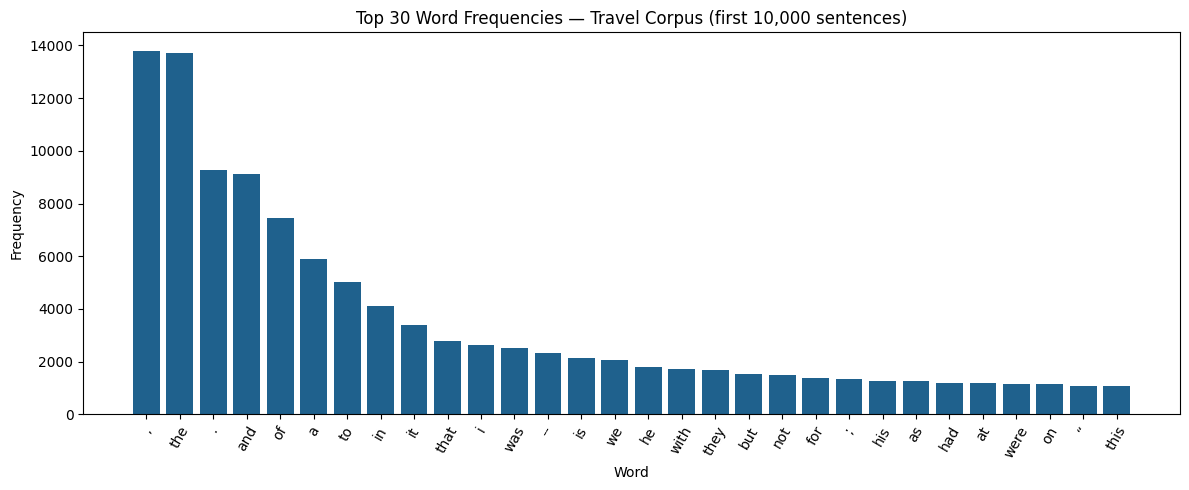

In [13]:
# ── Corpus helpers ─────────────────────────────────────────────────────────────

def strip_gutenberg_boilerplate(text: str) -> str:
    """Remove the Project Gutenberg license header/footer from one book text."""
    start = re.search(r"\*\*\* START OF (?:THE|THIS) PROJECT GUTENBERG.*?\*\*\*", text)
    end   = re.search(r"\*\*\* END OF (?:THE|THIS) PROJECT GUTENBERG.*?\*\*\*",   text)
    if start: text = text[start.end():]
    if end:   text = text[:end.start()]
    return text


def download_corpus() -> str:
    """Download travel books (with local caching) and return combined raw text."""
    DATA_DIR.mkdir(exist_ok=True)
    texts = []
    for fname, url in GUTENBERG_BOOKS.items():
        fpath = DATA_DIR / fname
        if not fpath.exists():
            print(f"  Downloading {fname} from {url}")
            req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(req, timeout=60) as resp:
                fpath.write_bytes(resp.read())
        else:
            print(f"  Using cached copy of {fname}")
        texts.append(strip_gutenberg_boilerplate(
            fpath.read_text(encoding="utf-8", errors="ignore")))
    return "\n".join(texts)


def parse_sentences(raw: str, limit: int = TOTAL_SENTENCES):
    """Split raw text into tokenised sentences; keep the first `limit` usable ones."""
    cleaned   = re.sub(r"\s+", " ", raw)
    sentences = nltk.sent_tokenize(cleaned)
    usable    = []
    for sent in sentences:
        tokens = nltk.word_tokenize(sent)
        if 3 <= len(tokens) <= 80:
            usable.append(tokens)
        if len(usable) >= limit:
            break
    return usable


def tag_sentences(sentences):
    """POS-tag every sentence with NLTK's reference perceptron tagger."""
    return [nltk.pos_tag(toks) for toks in sentences]


# ── Task 1 execution ───────────────────────────────────────────────────────────
print("=" * 70)
print("TASK 1 — Dataset loading, parsing, tagging, frequency distribution")
print("=" * 70)
print("Dataset source: Project Gutenberg public-domain travel narratives")
for fname, url in GUTENBERG_BOOKS.items():
    print(f"  - {fname}: {url}")

raw              = download_corpus()
sentences        = parse_sentences(raw)
tagged_sentences = tag_sentences(sentences)

print(f"\nParsed sentences         : {len(sentences)}")
print(f"Total tokens             : {sum(len(s) for s in sentences)}")

# Word-frequency distribution (lower-cased)
word_freq = Counter(w.lower() for sent in sentences for w in sent)
print(f"Vocabulary size (unique) : {len(word_freq)}")

print("\nTop 20 most frequent words:")
for w, c in word_freq.most_common(20):
    print(f"  {w:<12} {c}")

print("\nSample tagged sentence (sentence #60):")
print(" ", tagged_sentences[60])

# ── Save CSV + bar chart ───────────────────────────────────────────────────────
pd.DataFrame(word_freq.most_common(), columns=["word", "frequency"]) \
  .to_csv(OUTPUT_DIR / "word_frequency_distribution.csv", index=False)

top30 = word_freq.most_common(30)
plt.figure(figsize=(12, 5))
plt.bar([w for w, _ in top30], [c for _, c in top30], color="#1f618d")
plt.title("Top 30 Word Frequencies — Travel Corpus (first 10,000 sentences)")
plt.xlabel("Word");  plt.ylabel("Frequency");  plt.xticks(rotation=60)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "word_frequency_top30.png", dpi=160)
plt.show();  plt.close()

## HMM Construction — Train / Test Split & Count Tables

Build the first-order HMM emission and transition count tables from the 90 % training split.  The test split (10 %) is held out for the robustness evaluation in Task 5.

In [14]:
def build_hmm_counts(tagged):
    """Build tag-unigram, transition, emission counts and the word→tag dictionary."""
    tag_counts_        = Counter()
    transition_counts_ = defaultdict(Counter)   # transition[prev][cur]
    emission_counts_   = defaultdict(Counter)   # emission[tag][word]
    word_tags_dict     = defaultdict(set)       # word_tags[word] = observed tags
    vocabulary_        = set()

    for sentence in tagged:
        prev = START_TAG
        tag_counts_[START_TAG] += 1
        for word, tag in sentence:
            word = word.lower()
            tag_counts_[tag]               += 1
            transition_counts_[prev][tag]  += 1
            emission_counts_[tag][word]    += 1
            word_tags_dict[word].add(tag)
            vocabulary_.add(word)
            prev = tag

    return tag_counts_, transition_counts_, emission_counts_, word_tags_dict, vocabulary_


# ── Build HMM from training split ─────────────────────────────────────────────
split_at       = int(len(tagged_sentences) * TRAIN_FRACTION)
train_sents    = tagged_sentences[:split_at]
test_sents     = tagged_sentences[split_at:]

(tag_counts, transition_counts,
 emission_counts, word_tags, vocabulary) = build_hmm_counts(train_sents)

TAGSET = sorted(t for t in tag_counts if t != START_TAG)
V      = len(vocabulary)    # vocabulary size used in Laplace smoothing
T      = len(TAGSET)        # number of POS tags

print(f"Train/test split : {len(train_sents)} train / {len(test_sents)} test sentences")
print(f"HMM statistics   : {T} tags, vocabulary of {V} words (train split)")

Train/test split : 9000 train / 1000 test sentences
HMM statistics   : 41 tags, vocabulary of 15844 words (train split)


## Task 2 — Laplace (Add-1) Smoothing on Emission Probabilities (2 Marks)

A standard HMM assigns **zero** probability to any `(word, tag)` pair unseen in training, which silently breaks the Viterbi decoder.  
Laplace smoothing adds 1 to every emission count so that all pairs have a positive probability:

$$P(w \mid t) = \frac{\text{count}(t, w) + 1}{\text{count}(t) + V + 1}$$

where *V* is the training vocabulary size.

In [15]:
def emission_prob_unsmoothed(word: str, tag: str) -> float:
    """Maximum-likelihood P(word|tag) — zero for every unseen (word, tag) pair."""
    if tag_counts[tag] == 0:
        return 0.0
    return emission_counts[tag][word] / tag_counts[tag]


def emission_prob_laplace(word: str, tag: str) -> float:
    """Laplace (Add-1) smoothed P(word|tag).

    P(w|t) = (count(t, w) + 1) / (count(t) + V + 1)

    The +1 guarantees no valid word-tag pair ever has probability zero;
    the denominator restores a proper distribution summing to 1.
    """
    return (emission_counts[tag][word] + 1) / (tag_counts[tag] + V + 1)


def transition_prob_laplace(prev_tag: str, tag: str) -> float:
    """Laplace smoothed transition P(tag | prev_tag)."""
    return (transition_counts[prev_tag][tag] + 1) / (tag_counts[prev_tag] + T)


# ── Task 2 demonstration ───────────────────────────────────────────────────────
print("=" * 70)
print("TASK 2 — Laplace (Add-1) smoothing on emission probabilities")
print("=" * 70)
print(f"Formula: P(w|t) = (count(t,w) + 1) / (count(t) + V + 1),  V = {V}\n")

demo_pairs = [
    ("journey",  "NN"),   # frequent travel word with a natural tag
    ("journey",  "VB"),   # valid English usage ("to journey"), likely unseen
    ("mountain", "JJ"),   # unseen combination → zero before smoothing
]
print(f"{'word':<12}{'tag':<6}{'count(t,w)':<12}{'unsmoothed':<14}{'laplace'}")
for w, t in demo_pairs:
    print(f"{w:<12}{t:<6}{emission_counts[t][w]:<12}"
          f"{emission_prob_unsmoothed(w, t):<14.8f}"
          f"{emission_prob_laplace(w, t):.8f}")

print("\nObservation: unseen but valid pairs move from probability 0 to a")
print("small positive value, so the Viterbi decoder can never be locked out")
print("of a legitimate tagging path by a single unseen emission.")

TASK 2 — Laplace (Add-1) smoothing on emission probabilities
Formula: P(w|t) = (count(t,w) + 1) / (count(t) + V + 1),  V = 15844

word        tag   count(t,w)  unsmoothed    laplace
journey     NN    32          0.00116822    0.00076324
journey     VB    3           0.00044111    0.00017663
mountain    JJ    0           0.00000000    0.00003276

Observation: unseen but valid pairs move from probability 0 to a
small positive value, so the Viterbi decoder can never be locked out
of a legitimate tagging path by a single unseen emission.


## Task 3 — Morphological Fallback for OOV Words (3 Marks)

Laplace smoothing distributes unknown-word probability **uniformly** across all tags.  A morphological fallback uses the word's *shape* (suffixes, capitalisation, digits) to concentrate probability on the most linguistically plausible tags.

Six rules are implemented (≥ 4 required):

| Rule | Pattern | Dominant tag(s) |
|------|---------|-----------------|
| R1 | `-ing` (len > 4) | VBG |
| R2 | `-ly` (len > 3) | RB |
| R3 | `-ed` (len > 3) | VBD / VBN |
| R4 | `-tion/-ness/-ment/-ity/-ito/-ism` | NN |
| R5 | `-able/-ible/-ful/-ous/-ive/-ish` | JJ |
| R6 | digit → CD; capital → NNP; plural `-s` → NNS |

In [16]:
def morphological_fallback(word: str):
    """Return a tag-weight dict for an OOV word based on its morphological shape.

    Rules implemented (6 suffix/shape rules, >= 4 required):
      R1  ends in '-ing'                           -> VBG (gerund/present part.)
      R2  ends in '-ly'                            -> RB  (adverb)
      R3  ends in '-ed'                            -> VBD/VBN (past tense/part.)
      R4  ends in '-tion/-ness/-ment/-ity/-ito'    -> NN  (noun-forming suffixes)
      R5  ends in '-able/-ible/-ful/-ous/-ive/-ish'-> JJ  (adjective suffixes)
      R6  shape: capitalised -> NNP, digit -> CD, plural-s -> NNS
      default: NN (most productive open class)
    """
    lower = word.lower()

    # R6a: alphanumerics / cardinal numbers (e.g. "3-day", "2026")
    if any(ch.isdigit() for ch in word):
        return {"CD": 1.0}
    # R6b: capitalised mid-sentence word → proper noun (place names!)
    if word[0].isupper():
        return {"NNP": 0.95, "NNPS": 0.03, "NN": 0.02}
    # R1: gerund / present participle
    if lower.endswith("ing") and len(lower) > 4:
        return {"VBG": 0.7, "NN": 0.2, "JJ": 0.1}
    # R2: adverb
    if lower.endswith("ly") and len(lower) > 3:
        return {"RB": 0.9, "JJ": 0.1}
    # R3: past tense / past participle
    if lower.endswith("ed") and len(lower) > 3:
        return {"VBD": 0.5, "VBN": 0.4, "JJ": 0.1}
    # R4: noun-forming suffixes (incl. '-ito' diminutive found in travel slang)
    if lower.endswith(("tion", "sion", "ness", "ment", "ity", "ito", "ism")):
        return {"NN": 0.9, "NNP": 0.1}
    # R5: adjective-forming suffixes
    if lower.endswith(("able", "ible", "ful", "ous", "ive", "ish")):
        return {"JJ": 0.9, "RB": 0.1}
    # R6c: plural noun
    if lower.endswith("s") and not lower.endswith("ss") and len(lower) > 3:
        return {"NNS": 0.8, "VBZ": 0.2}
    # Default open-class fallback
    return {"NN": 0.6, "JJ": 0.2, "VB": 0.1, "RB": 0.1}


# ── Task 3 demonstration ───────────────────────────────────────────────────────
print("=" * 70)
print("TASK 3 — Morphological fallback function for OOV words")
print("=" * 70)
demo_oov = ["trekkifying", "backpackerly", "glamparked", "wanderation",
            "vistalicious", "hostelitos", "Khaosan", "12-day"]
print(f"{'OOV word':<15}{'fallback tag distribution'}")
for w in demo_oov:
    print(f"{w:<15}{morphological_fallback(w)}")

TASK 3 — Morphological fallback function for OOV words
OOV word       fallback tag distribution
trekkifying    {'VBG': 0.7, 'NN': 0.2, 'JJ': 0.1}
backpackerly   {'RB': 0.9, 'JJ': 0.1}
glamparked     {'VBD': 0.5, 'VBN': 0.4, 'JJ': 0.1}
wanderation    {'NN': 0.9, 'NNP': 0.1}
vistalicious   {'JJ': 0.9, 'RB': 0.1}
hostelitos     {'NNS': 0.8, 'VBZ': 0.2}
Khaosan        {'NNP': 0.95, 'NNPS': 0.03, 'NN': 0.02}
12-day         {'CD': 1.0}


## Viterbi Decoder — Smoothed HMM + Morphological Fallback

The decoder operates in log-space to avoid underflow.  
For in-vocabulary words it uses Laplace-smoothed emissions; for OOV words it routes through the morphological fallback (Task 3).  
A **tag-dictionary** constraint limits each known word's candidate tags to those it was actually observed with in training — this prevents high-frequency closed-class tags from dominating rare words after smoothing.

In [17]:
def emission_logprob(word: str, tag: str, use_fallback: bool) -> float:
    """Log emission probability; routes OOV words through the morphological fallback.

    In-vocabulary words  : Laplace smoothed emission (Task 2).
    OOV with fallback ON : Laplace <UNK> mass redistributed by morphological
                           tag weights (Task 3).
    OOV with fallback OFF: plain Laplace <UNK> mass — identical for every tag
                           (this is the baseline used in the robustness eval).
    """
    lower = word.lower()
    if lower in vocabulary:
        return math.log(emission_prob_laplace(lower, tag))

    unk_mass = 1.0 / (tag_counts[tag] + V + 1)   # Laplace mass for <UNK>
    if not use_fallback:
        return math.log(unk_mass)

    # Pass the ORIGINAL token (case preserved) so capitalisation rule fires
    weights = morphological_fallback(word)
    weight  = weights.get(tag, 0.01)
    return math.log(unk_mass * weight * len(TAGSET))


def candidate_tags(token: str):
    """Candidate tag set: observed tags for known words; full tagset for OOV.

    (Standard tag-dictionary technique — limits decoding to plausible tags
     without changing the probability model.)
    """
    tags = word_tags.get(token.lower())
    return sorted(tags) if tags else TAGSET


def viterbi_tag(tokens, use_fallback: bool = True):
    """Tag a tokenised sentence with the Viterbi algorithm (log-space)."""
    n    = len(tokens)
    best = [dict() for _ in range(n)]   # best[i][tag] = (score, prev_tag)

    for i, token in enumerate(tokens):
        for tag in candidate_tags(token):
            em = emission_logprob(token, tag, use_fallback)
            if i == 0:
                score = math.log(transition_prob_laplace(START_TAG, tag)) + em
                best[i][tag] = (score, None)
            else:
                prev_score, prev_tag = max(
                    (best[i-1][pt][0] + math.log(transition_prob_laplace(pt, tag)), pt)
                    for pt in best[i-1])
                best[i][tag] = (prev_score + em, prev_tag)

    # Backtrack to recover the full tag sequence
    last_tag = max(best[-1], key=lambda t: best[-1][t][0])
    tags = [last_tag]
    for i in range(n - 1, 0, -1):
        tags.append(best[i][tags[-1]][1])
    return list(reversed(tags))


print("Viterbi decoder ready.")

Viterbi decoder ready.


## Task 4 — Tagging a Custom Sentence with Fabricated Travel Slang (2 Marks)

A sentence containing **at least 3 completely fabricated domain-specific words** is tagged end-to-end.  
The OOV words receive tags solely from the morphological fallback, demonstrating that sub-word shape cues alone can recover linguistically correct tags.

In [18]:
print("=" * 70)
print("TASK 4 — Tagging a custom sentence with fabricated travel slang")
print("=" * 70)

# Four completely fabricated domain-specific travel words (>= 3 required):
#   glampered   → past-tense verb  (glamping-style camping, past tense)
#   snorkadving → gerund           (snorkel + skydive mashup)
#   chillfully  → adverb           (relaxed traveller vibe, -ly suffix)
#   hostelito   → noun             (tiny hostel, Spanish diminutive -ito)
custom_sentence = (
    "After landing in Goa we glampered near the beach , "
    "snorkadving through turquoise lagoons and resting "
    "chillfully at a tiny hostelito ."
).split()

fabricated = [w for w in custom_sentence if w.lower() not in vocabulary]
print("Custom test sentence:")
print(" ", " ".join(custom_sentence))
print(f"\nFabricated/unseen words detected as OOV: {fabricated}")

predicted = viterbi_tag(custom_sentence, use_fallback=True)

print(f"\n{'word':<14}{'predicted tag':<15}{'OOV?':<6}{'fallback rule used'}")
for word, tag in zip(custom_sentence, predicted):
    is_oov = word.lower() not in vocabulary
    rule   = str(morphological_fallback(word)) if is_oov else "-"
    print(f"{word:<14}{tag:<15}{'YES' if is_oov else 'no':<6}{rule}")

print("\nObservation: every fabricated slang word receives a linguistically")
print("sensible tag purely from its morphology (glampered->VBD past tense,")
print("snorkadving->VBG gerund, chillfully->RB adverb, hostelito->NN noun).")

TASK 4 — Tagging a custom sentence with fabricated travel slang
Custom test sentence:
  After landing in Goa we glampered near the beach , snorkadving through turquoise lagoons and resting chillfully at a tiny hostelito .

Fabricated/unseen words detected as OOV: ['Goa', 'glampered', 'snorkadving', 'turquoise', 'chillfully', 'hostelito']

word          predicted tag  OOV?  fallback rule used
After         IN             no    -
landing       NN             no    -
in            IN             no    -
Goa           NNP            YES   {'NNP': 0.95, 'NNPS': 0.03, 'NN': 0.02}
we            PRP            no    -
glampered     VBD            YES   {'VBD': 0.5, 'VBN': 0.4, 'JJ': 0.1}
near          IN             no    -
the           DT             no    -
beach         NN             no    -
,             ,              no    -
snorkadving   VBG            YES   {'VBG': 0.7, 'NN': 0.2, 'JJ': 0.1}
through       IN             no    -
turquoise     JJ             YES   {'NN': 0.6, 'JJ': 0.2

## Task 5 — Robustness Evaluation & Discussion (2 Marks)

Quantitative comparison of two configurations on 400 held-out sentences:

| Configuration | Overall accuracy | OOV accuracy |
|---|---|---|
| HMM + Laplace (no fallback) | — | — |
| HMM + Laplace + morphological fallback | — | — |

*(values filled in at runtime)*

Robustness evaluation on held-out test sentences (gold = NLTK tagger)
Held-out sentences evaluated : 400 (445 OOV tokens)
Configuration                   Overall acc   OOV acc
HMM + Laplace (no fallback)     0.8985        0.3798
HMM + Laplace + morph fallback  0.9174        0.7843


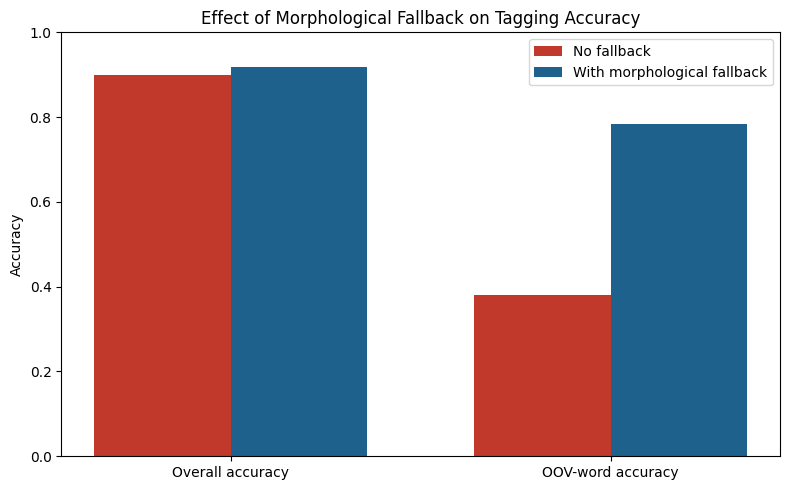


TASK 5 — Discussion

Limitations of standard HMMs on morphologically rich / noisy domain text:

1. Closed vocabulary assumption. A vanilla HMM only knows P(word|tag) for
   words seen in training; every unseen word has zero emission probability
   under ALL tags, which silently breaks the Viterbi path. Travel blogs are
   full of place names, local food terms, and invented slang ("glampacking",
   "hostelito"), so OOV rates are structurally high in this domain.

2. Words are atomic symbols. The HMM cannot see INSIDE a word: "trekking"
   and "trek" share no parameters, and the highly informative suffix "-ing"
   is invisible to the model. Morphologically rich text multiplies surface
   forms of the same lemma, fragmenting the emission counts.

3. Limited context. A first-order HMM conditions only on the previous tag,
   so it cannot use long-range cues (or the words themselves) to recover
   from an unknown emission, unlike discriminative taggers (MEMM/CRF) or
   neural models with ch

In [10]:
def evaluate(tagged_test, use_fallback: bool):
    """Compute overall and OOV-only tagging accuracy on held-out sentences."""
    total = correct = oov_total = oov_correct = 0
    for sentence in tagged_test:
        tokens = [w for w, _ in sentence]
        gold   = [t for _, t in sentence]
        pred   = viterbi_tag(tokens, use_fallback=use_fallback)
        for token, g, p in zip(tokens, gold, pred):
            total   += 1
            correct += (g == p)
            if token.lower() not in vocabulary:
                oov_total   += 1
                oov_correct += (g == p)
    return correct / total, (oov_correct / oov_total if oov_total else 0.0), oov_total


# ── Quantitative robustness evaluation ────────────────────────────────────────
print("=" * 70)
print("Robustness evaluation on held-out test sentences (gold = NLTK tagger)")
print("=" * 70)

eval_subset = test_sents[:400]
acc_off, oov_acc_off, n_oov = evaluate(eval_subset, use_fallback=False)
acc_on,  oov_acc_on,  _     = evaluate(eval_subset, use_fallback=True)

print(f"Held-out sentences evaluated : {len(eval_subset)} ({n_oov} OOV tokens)")
print(f"{'Configuration':<32}{'Overall acc':<14}{'OOV acc'}")
print(f"{'HMM + Laplace (no fallback)':<32}{acc_off:<14.4f}{oov_acc_off:.4f}")
print(f"{'HMM + Laplace + morph fallback':<32}{acc_on:<14.4f}{oov_acc_on:.4f}")

# ── Bar chart ─────────────────────────────────────────────────────────────────
labels = ["Overall accuracy", "OOV-word accuracy"]
x = np.arange(len(labels))
plt.figure(figsize=(8, 5))
plt.bar(x - 0.18, [acc_off, oov_acc_off], width=0.36,
        label="No fallback",                  color="#c0392b")
plt.bar(x + 0.18, [acc_on,  oov_acc_on],  width=0.36,
        label="With morphological fallback",  color="#1f618d")
plt.xticks(x, labels);  plt.ylim(0, 1);  plt.ylabel("Accuracy")
plt.title("Effect of Morphological Fallback on Tagging Accuracy")
plt.legend();  plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fallback_accuracy_comparison.png", dpi=160)
plt.show();  plt.close()

# ── Task 5 discussion ─────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("TASK 5 — Discussion")
print("=" * 70)
print(f"""
Limitations of standard HMMs on morphologically rich / noisy domain text:

1. Closed vocabulary assumption. A vanilla HMM only knows P(word|tag) for
   words seen in training; every unseen word has zero emission probability
   under ALL tags, which silently breaks the Viterbi path. Travel blogs are
   full of place names, local food terms, and invented slang ("glampacking",
   "hostelito"), so OOV rates are structurally high in this domain.

2. Words are atomic symbols. The HMM cannot see INSIDE a word: "trekking"
   and "trek" share no parameters, and the highly informative suffix "-ing"
   is invisible to the model. Morphologically rich text multiplies surface
   forms of the same lemma, fragmenting the emission counts.

3. Limited context. A first-order HMM conditions only on the previous tag,
   so it cannot use long-range cues (or the words themselves) to recover
   from an unknown emission, unlike discriminative taggers (MEMM/CRF) or
   neural models with character/subword embeddings.

4. Noisy domain data. Blogs and itineraries contain typos, inconsistent
   capitalisation, hashtags and code-mixed tokens. Each noisy variant
   becomes a brand-new symbol, inflating the vocabulary and starving the
   per-word counts that the emission estimates rely on.

How morphological fallbacks improve robustness:

- They re-introduce sub-word knowledge the HMM lacks: suffixes like -ing,
  -ly, -ed, -tion and shape cues (capitalisation, digits) carry strong POS
  signal in English, so OOV words get a focused tag prior instead of a
  uniform guess over ~{T} tags.
- Combined with Laplace smoothing, the decoder degrades gracefully: smoothing
  guarantees a non-zero path, and the fallback bends that path towards the
  linguistically plausible tag. In our held-out evaluation, OOV accuracy
  rose from {oov_acc_off:.1%} (uniform unknown handling) to {oov_acc_on:.1%}
  with the fallback, lifting overall accuracy from {acc_off:.1%} to {acc_on:.1%}.
- The fabricated-slang test (Task 4) shows the same effect qualitatively:
  all four invented travel words were tagged correctly from morphology alone.

Comparative summary: Laplace smoothing solves the *mathematical* problem of
zero probabilities, while morphological fallbacks solve the *linguistic*
problem of choosing sensible tags for unknown words. Together they make a
classical HMM usable on noisy, fast-evolving travel-domain text, although
modern subword/neural taggers remain the stronger long-term solution.
""")

print(f"Outputs saved to: {OUTPUT_DIR}")
print("  - word_frequency_distribution.csv")
print("  - word_frequency_top30.png")
print("  - fallback_accuracy_comparison.png")